# OpenCourses.AI Colab version

This notebook belongs to **Fundamentos de Transformers** and was published as a public Colab-ready artifact.

Colab is an external free execution option with variable resources. Run the setup cell before executing the rest of the notebook.


In [ ]:
# OpenCourses.AI Colab setup
import os, pathlib, subprocess, sys
REPO_URL = "https://github.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb.git"
BRANCH = "main"
TARGET = pathlib.Path("/content/opencourses/opencourse-fundamentos-de-transformers-d9d23ccb")
TARGET.parent.mkdir(parents=True, exist_ok=True)
if not TARGET.exists():
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(TARGET)], check=True)
os.environ['COURSE_ROOT'] = str(TARGET)
os.environ['ASSETS_DIR'] = str(TARGET / 'assets')
notebooks_dir = TARGET / 'notebooks'
if notebooks_dir.exists():
    os.chdir(notebooks_dir)
requirements = TARGET / 'requirements.txt'
if requirements.exists() and requirements.read_text(encoding='utf8').strip():
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(requirements)], check=True)
print(f'COURSE_ROOT={TARGET}')


<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Fundamentos de Transformers</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 15</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Generación, interpretación y límites</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Curso abierto</div>
    </div>
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
    <div><strong>Curso:</strong> Fundamentos de Transformers</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>


## Presentación del notebook

<audio controls style="width: 100%; margin: 8px 0 18px 0;">
  <source src="../assets/audio/notebooks/15_generacion_interpretacion_y_limites_intro.mp3" type="audio/mpeg">
  Su navegador no puede reproducir el audio embebido.
</audio>


## Pregunta directriz

> ¿Cómo se convierten los logits de un mini-GPT entrenado en texto generado y qué límites aparecen al interpretar esa salida?

En el notebook 14 entrenamos un modelo pequeño para reducir la pérdida de predicción del siguiente token. En este notebook usamos ese mismo tipo de modelo para generar texto token por token, comparando estrategias de muestreo y revisando por qué una salida aparentemente fluida no debe confundirse con comprensión lingüística robusta.

La pregunta es importante porque la generación no es un paso mágico: en cada iteración se toma el contexto, se calculan logits, se transforman en una distribución, se elige un token y se realimenta el resultado.


## Objetivos

Al finalizar este notebook, el estudiante debería poder:

1. Explicar el ciclo autoregresivo de generación desde un prompt hasta un nuevo token.
2. Comparar greedy, temperatura, top-k y top-p manteniendo fijo el prompt.
3. Inspeccionar logits, probabilidades y candidatos principales para una vuelta generativa.
4. Leer un mapa de atención durante generación sin convertirlo en una explicación causal completa.
5. Reconocer límites: repetición, incoherencia, sensibilidad al corpus y sobreinterpretación de salidas pequeñas.


## Marco conceptual

Generar texto con un mini-GPT consiste en repetir una operación local: tomar el contexto disponible, recortarlo al `block_size`, calcular logits para la última posición, convertir esos logits en una distribución y seleccionar el siguiente token. El token seleccionado se agrega al contexto y cambia las predicciones posteriores.

La cadena conceptual del notebook es:

$$
\text{prompt} \rightarrow \text{contexto recortado} \rightarrow \text{logits última posición} \rightarrow \text{temperatura/filtros} \rightarrow \text{distribución} \rightarrow \text{muestra} \rightarrow \text{nuevo contexto}.
$$

Cambiar la estrategia de muestreo modifica cómo se elige el siguiente token, pero no cambia los parámetros del modelo. Si el entrenamiento fue insuficiente o el corpus es pobre, el muestreo puede alterar variedad y repetición, pero no crea conocimiento que el modelo no aprendió.


## Idea visual: generación autoregresiva

<div style="text-align: center; margin: 12px 0 18px 0;">
  <img src="../assets/figures/15_generacion_interpretacion_y_limites.png" alt="Generación, interpretación y límites" style="width: min(980px, 98%); height: auto; border: 1px solid #d0d7de; border-radius: 6px;">
</div>

La figura resume el ciclo generativo y sus puntos de decisión: prompt, recorte a `block_size`, logits de la última posición, filtros, softmax, muestra y realimentación. Su función es orientar la lectura; la evidencia técnica sigue estando en las formas tensoriales, las probabilidades y las salidas observadas.

## Formulación matemática

Sea $x_{\leq t}$ el contexto disponible hasta la posición $t$, $|\mathcal V|$ el tamaño del vocabulario y $z_t\in\mathbb{R}^{|\mathcal V|}$ el vector de logits producido para la última posición del contexto.

El modelo produce logits para todas las posiciones del contexto recortado, pero durante generación se usa solo la última fila:

$$
Z=f_\theta(x_{\leq t}),
\qquad
z_t=Z_{\text{última posición},:}.
$$

Esta ecuación se lee así: el modelo calcula puntajes para cada posición visible, pero el siguiente token se decide únicamente con los logits de la última posición.

La distribución base se obtiene con softmax:

$$
p_\theta(x_{t+1}=v\mid x_{\leq t})=
\operatorname{softmax}(z_t)_v.
$$

Esta ecuación se lee así: para cada token candidato $v$, el modelo asigna una probabilidad condicional de ser el siguiente token.

La temperatura $\tau>0$ reescala los logits antes del softmax:

$$
p_\theta^{(\tau)}(v\mid x_{\leq t})=
\operatorname{softmax}\left(\frac{z_t}{\tau}\right)_v.
$$

Esta ecuación se lee así: con $\tau$ menor, la distribución se concentra más; con $\tau$ mayor, se vuelve más dispersa. La temperatura no entrena el modelo: solo cambia la forma de la distribución usada para muestrear.

Top-k conserva los $k$ tokens de mayor puntaje. Top-p conserva el conjunto mínimo $P$ cuya probabilidad acumulada alcanza un umbral $p$:

$$
\sum_{v\in P} p_\theta^{(\tau)}(v\mid x_{\leq t}) \geq p.
$$

Esta ecuación se lee así: top-p no fija un número de tokens; fija una masa de probabilidad acumulada.

El token generado se obtiene muestreando de la distribución filtrada:

$$
x_{t+1}\sim \tilde{p}_\theta(\cdot\mid x_{\leq t}).
$$

Esta ecuación se lee así: el siguiente token es una muestra, no una conclusión semántica garantizada.

El contexto se actualiza y, si crece demasiado, se recorta:

$$
x_{\leq t+1} = \operatorname{append}(x_{\leq t}, x_{t+1}),
\qquad
x_{cond}=x_{\leq t+1}[-\text{block\_size}:].
$$

Esta ecuación se lee así: el token elegido se agrega al contexto, y la siguiente vuelta solo conserva las últimas posiciones que caben en `block_size`.

## Traducción tensorial

Durante generación, el contexto suele tener forma `(1,T')`, donde $T'$ puede crecer con cada token generado. Como el modelo solo acepta hasta `block_size`, se usa `idx[:, -block_size:]` para conservar las últimas posiciones.

Una vuelta del ciclo usa estos objetos:

| Paso | Objeto | Forma típica | Lectura |
|---|---|---:|---|
| Contexto recortado | `idx_cond` | `(1,T')` | tokens visibles para predecir |
| Modelo | `logits` | `(1,T',Vocab)` | puntajes por posición y vocabulario |
| Última posición | `last_logits = logits[:, -1, :]` | `(1,Vocab)` | candidatos para el siguiente token |
| Filtros | temperatura/top-k/top-p | `(1,Vocab)` | cambian candidatos disponibles |
| Distribución | `probs` | `(1,Vocab)` | probabilidades después de softmax |
| Muestra | `next_id` | `(1,1)` | token elegido |
| Realimentación | `torch.cat` | `(1,T'+1)` | nuevo contexto |

Separar estas etapas evita confundir tres decisiones distintas: el modelo produce logits, los filtros definen una distribución de muestreo y la muestra elige un token concreto.

## Preparación del entorno


In [1]:
from pathlib import Path
import importlib
import sys
import warnings

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import torch

warnings.filterwarnings("ignore", message="Pandas requires version .*", category=UserWarning)
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import fundamentos_transformers.generacion_experimentos as generacion_experimentos
import fundamentos_transformers.visualizacion as visualizacion

generacion_experimentos = importlib.reload(generacion_experimentos)
visualizacion = importlib.reload(visualizacion)

configurar_matplotlib = visualizacion.configurar_matplotlib
mostrar_tablas_en_columnas = visualizacion.mostrar_tablas_en_columnas

configurar_matplotlib()
torch.manual_seed(7)
np.random.seed(7)


## Experimento: corpus y entrenamiento breve

Para observar generación sin introducir archivos externos, entrenamos un modelo pequeño sobre un corpus controlado y repetitivo. Esto permite comparar estrategias de muestreo, pero también limita seriamente lo que se puede concluir sobre calidad lingüística.


In [2]:
resultado_preparacion = generacion_experimentos.preparar_demo_generacion(seed=7)
corpus = resultado_preparacion.corpus
token_a_id = resultado_preparacion.token_a_id
id_a_token = resultado_preparacion.id_a_token
ids = resultado_preparacion.ids
BLOCK_SIZE = resultado_preparacion.block_size
CONFIG = resultado_preparacion.config
model = resultado_preparacion.model
history = resultado_preparacion.history

mostrar_tablas_en_columnas(
    [
        ("Resumen", resultado_preparacion.resumen),
        ("Configuración", resultado_preparacion.configuracion),
        ("Lectura crítica", resultado_preparacion.lectura),
    ],
    min_width="300px",
)


## Comparación de estrategias de generación

Mantendremos fijo el prompt y cambiaremos solo la estrategia de muestreo. Así se puede atribuir la diferencia observada a la forma de seleccionar tokens, no a un cambio de entrenamiento o de contexto inicial.


In [3]:
resultado_generaciones = generacion_experimentos.preparar_generaciones_comparadas(
    model,
    token_a_id,
    id_a_token,
    prompt="atencion",
)
prompt = resultado_generaciones.prompt
configuraciones = resultado_generaciones.configuraciones

mostrar_tablas_en_columnas(
    [
        ("Configuraciones de muestreo", resultado_generaciones.configuraciones_df),
        ("Generaciones con prompt fijo", resultado_generaciones.generaciones),
    ],
    min_width="360px",
)


## Inspección de una vuelta generativa

Ahora observamos una sola vuelta del ciclo. El objetivo es ver cómo un contexto produce logits, cómo los logits se vuelven probabilidades y qué tokens quedan como candidatos principales.


In [4]:
resultado_auditoria = generacion_experimentos.preparar_auditoria_vuelta_generativa(
    model,
    token_a_id,
    id_a_token,
    BLOCK_SIZE,
    prompt,
)
prompt_ids = resultado_auditoria.prompt_ids
idx_cond = resultado_auditoria.idx_cond
logits = resultado_auditoria.logits
last_logits = resultado_auditoria.last_logits
att = resultado_auditoria.attention

mostrar_tablas_en_columnas(
    [
        ("Auditoría de una vuelta", resultado_auditoria.auditoria),
        ("Top candidatos base", resultado_auditoria.top_base),
        ("Lectura del ciclo", resultado_auditoria.lectura),
    ],
    min_width="300px",
)


## Efecto de temperatura y filtros sobre candidatos

La siguiente tabla compara cómo cambia el conjunto visible de candidatos para la misma posición. Esto muestra que muestrear no modifica el modelo; modifica la distribución usada para seleccionar el próximo token.


In [5]:
resultado_filtros = generacion_experimentos.preparar_filtros_generacion(
    last_logits,
    id_a_token,
    configuraciones,
)

mostrar_tablas_en_columnas(
    [
        ("Resumen de filtros", resultado_filtros.resumen),
        ("Candidatos visibles", resultado_filtros.candidatos),
    ],
    min_width="360px",
)


estrategia,candidatos > 0,masa top-3,entropia aprox.,lectura
greedy / top_k=1,1,1.0000,-0.0000,un solo candidato disponible
temperatura + top_k,6,0.7188,1.6707,concentra y limita a k candidatos
temperatura + top_p,12,0.4504,2.3614,conserva una masa acumulada
estrategia,rank,token,token id,probabilidad
greedy / top_k=1,1,'t',15,1.0000
temperatura + top_k,1,'t',15,0.3042
temperatura + top_k,2,'a',2,0.2282
temperatura + top_k,3,' ',0,0.1864
temperatura + top_k,4,'e',5,0.1238
temperatura + top_k,5,'o',11,0.0844


## Traza de tres pasos generativos

La siguiente traza abre el ciclo autoregresivo durante tres pasos. Mantiene una estrategia fija y muestra cómo el token elegido se agrega al contexto antes de la siguiente predicción.

In [6]:
resultado_traza = generacion_experimentos.preparar_traza_generativa(
    model,
    token_a_id,
    id_a_token,
    prompt,
)

mostrar_tablas_en_columnas(
    [
        ("Traza generativa", resultado_traza.traza),
        ("Lectura", resultado_traza.lectura),
    ],
    min_width="360px",
)


## Visualización de atención durante generación

El mapa muestra pesos de atención de una cabeza en la primera capa para el prompt. Las filas son posiciones que consultan; las columnas son posiciones consultadas. Por la máscara causal, una posición no debe atender a tokens futuros.

Esta visualización ayuda a formular hipótesis sobre rutas de información, pero no prueba causalidad lingüística ni comprensión.

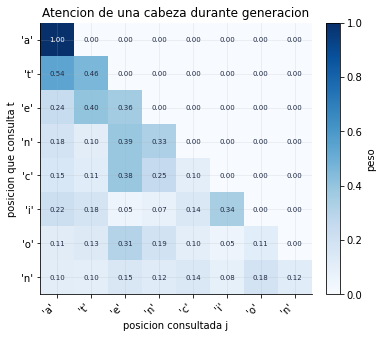

criterio,valor,lectura
forma attention,"(1, 4, 8, 8)","B,H,T,T"
cabeza visualizada,h=0,una sola cabeza de la primera capa
suma de filas,1.000 a 1.000,cada fila se normaliza
masa futura,0.000,la mascara causal bloquea j>t
cautela,necesaria,el mapa no explica por si solo la salida


In [7]:
resultado_atencion = generacion_experimentos.preparar_atencion_generacion(att, idx_cond, id_a_token)

display(resultado_atencion.figura)
plt.close(resultado_atencion.figura)

mostrar_tablas_en_columnas(
    [("Lectura del mapa de atención", resultado_atencion.lectura)],
    min_width="520px",
)


## Interpretación

Las generaciones muestran que diferentes estrategias pueden producir variación aun con el mismo prompt. Greedy aproximado tiende a concentrarse en la opción más probable; temperatura y filtros permiten explorar alternativas. Sin embargo, en un modelo pequeño entrenado sobre corpus repetitivo, mayor variedad también puede acelerar incoherencias o repeticiones.

El mapa de atención ayuda a formular preguntas sobre qué posiciones se mezclan, pero no prueba comprensión ni causalidad lingüística. Para interpretar el modelo hacen falta varias evidencias: datos, entrenamiento, curvas, generaciones, errores y límites.


## Verificación de aprendizaje

Mantenga fijo el prompt y cambie una sola variable: `temperature`, `top_k` o `top_p`. Registre en una tabla el texto generado, candidatos principales y una interpretación breve.

La consigna requiere evidencia: no basta decir que una estrategia “suena mejor”. Debe indicar qué cambió en la distribución, cuántos candidatos quedaron disponibles, cómo cambió la masa de los tokens principales y qué límite interpretativo se mantiene.

In [8]:
resultado_pruebas = generacion_experimentos.preparar_pruebas_muestreo(
    model,
    token_a_id,
    id_a_token,
    prompt,
    last_logits,
)

mostrar_tablas_en_columnas(
    [
        ("Pruebas de muestreo", resultado_pruebas.pruebas),
        ("Lectura esperada", resultado_pruebas.lectura),
    ],
    min_width="360px",
)


## Análisis crítico

**Qué ocurrió.** El mismo modelo produjo salidas distintas al cambiar temperatura, top-k o top-p, y la distribución de candidatos cambió sin reentrenar parámetros.

**Por qué ocurrió.** La generación usa los logits de la última posición. La temperatura reescala esos logits; top-k y top-p eliminan candidatos antes del muestreo. Luego el token elegido se agrega al contexto y afecta los pasos siguientes.

**Qué no se puede concluir.** Una salida localmente legible no demuestra comprensión, conocimiento factual ni capacidad de generalización. Con un corpus pequeño, muchas regularidades provienen de repetición y memorización parcial. Un mapa de atención aislado tampoco explica por sí solo por qué el texto resultó así.

**Lectura operacional.** Generar no es entrenar: los parámetros quedan fijos. Lo que cambia es la distribución desde la cual se elige el siguiente token y, después, el contexto que alimenta la siguiente vuelta.

## Síntesis

La cadena operacional del notebook es:

$$
\text{prompt} \rightarrow x_{\leq t} \rightarrow z_t \rightarrow \tilde{p}_\theta(\cdot\mid x_{\leq t}) \rightarrow x_{t+1} \rightarrow x_{\leq t+1} \rightarrow \text{análisis de límites}.
$$

Esta cadena se lee así: el prompt se convierte en contexto, el modelo produce logits, la estrategia de muestreo define una distribución filtrada, se selecciona un token y ese token modifica el contexto posterior.

<div style="border-left: 4px solid #1f2a44; padding: 10px 14px; background: #f6f8fa; margin-top: 10px;">
La idea central es que generar texto no equivale a comprenderlo: es un procedimiento autoregresivo que debe analizarse junto con datos, entrenamiento, muestreo y errores observables.
</div>


## Preguntas de discusión

1. ¿Por qué la generación usa los logits de la última posición del contexto?
2. ¿Qué diferencia matemática hay entre temperatura, top-k y top-p?
3. ¿Por qué mantener fijo el prompt ayuda a comparar estrategias de muestreo?
4. ¿Qué no debemos inferir de un mapa de atención aislado?
5. ¿Qué evidencias debería incluir el proyecto final para defender una generación producida por un mini Transformer?


## Continuidad

El notebook 16 integra la ruta completa en un proyecto final. La entrega debe conectar datos, tokenización, arquitectura, entrenamiento, generación, visualización y límites, evitando presentar una salida llamativa como evidencia suficiente de comprensión.
